Caricamento dati in corso...
Ecco come appaiono i dati:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Distribuzione delle classi:
Class
0    284315
1       492
Name: count, dtype: int64


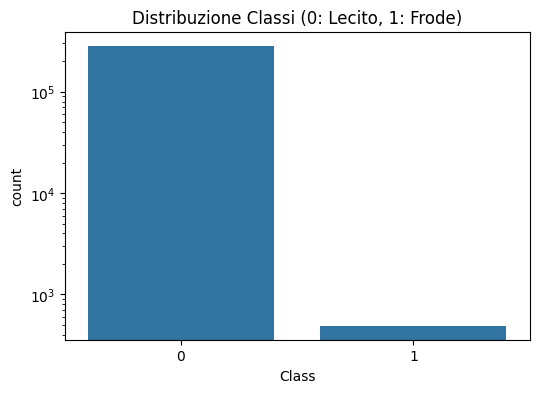


Le frodi rappresentano solo il 0.173% del totale.


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#caricamento dati
print("Caricamento dati in corso...")
df = pd.read_csv('creditcard.csv')

print("Ecco come appaiono i dati:")
display(df.head())

#Analisi dello sbilanciamento, problema chiave
#La colonna class vale 0 per transazioni valide, 1 per frodi
counts = df['Class'].value_counts()
print("\nDistribuzione delle classi:")
print(counts)

#Visualizziamola differnza
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Distribuzione Classi (0: Lecito, 1: Frode)')
plt.yscale('log') #uso scala logaritmica perché le frodi sono poche
plt.show()

#Calcolo percentuale di frodi
fraud_share = counts[1]/len(df)*100
print(f"\nLe frodi rappresentano solo il {fraud_share:.3f}% del totale.")


Addestramento in corso...
Test del modello sui dati mai visti...


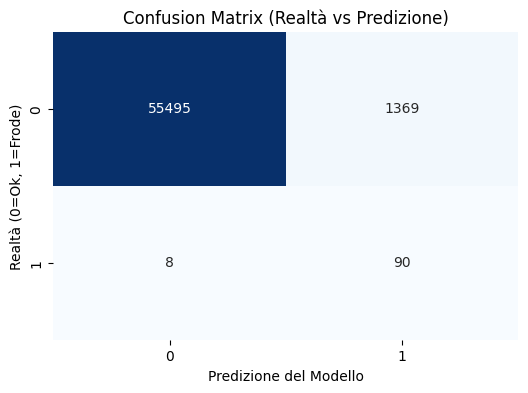

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

#Preparazione delle Feature (X) e del Target (y)
X = df.drop(['Class', 'Time'], axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')
print("Addestramento in corso...")
model.fit(X_train, y_train)
print("Test del modello sui dati mai visti...")
y_pred = model.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)

#Visualizzazione
plt.figure(figsize=(6,4), dpi=100)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix (Realtà vs Predizione)")
plt.ylabel("Realtà (0=Ok, 1=Frode)")
plt.xlabel("Predizione del Modello")
plt.show()
print(classification_report(y_test, y_pred))




Esempi di probabilità di frode calcolate dal modello:
[1.         0.01991873 0.01657381 0.02917319 0.01921958]


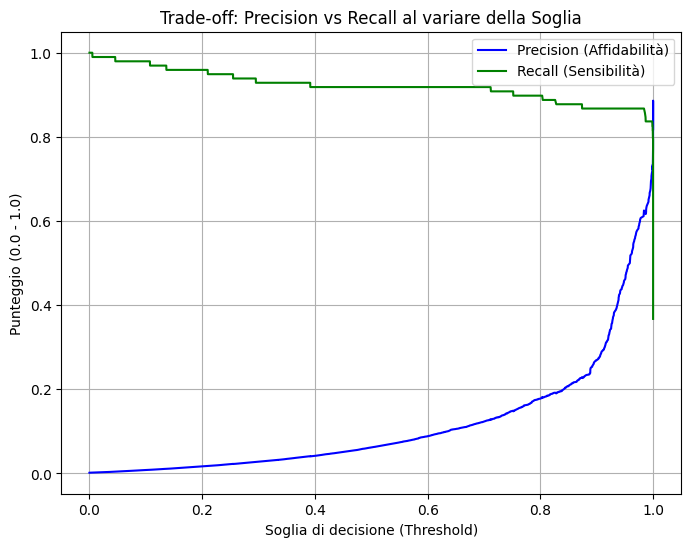

In [9]:
from sklearn.metrics import precision_recall_curve

y_scores = model.predict_proba(X_test)[:, 1]
print("Esempi di probabilità di frode calcolate dal modello:")
print(y_scores[:5])
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], label="Precision (Affidabilità)", color="blue")
plt.plot(thresholds, recalls[:-1], label="Recall (Sensibilità)", color="green")
plt.xlabel("Soglia di decisione (Threshold)")
plt.ylabel("Punteggio (0.0 - 1.0)")
plt.title("Trade-off: Precision vs Recall al variare della Soglia")
plt.legend()
plt.grid(True)
plt.show()

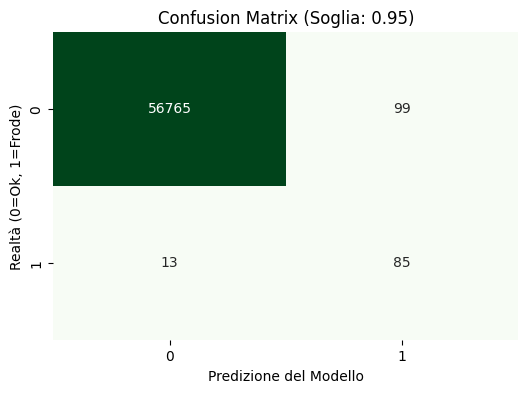

--- REPORT CON SOGLIA AL 95.0% ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.46      0.87      0.60        98

    accuracy                           1.00     56962
   macro avg       0.73      0.93      0.80     56962
weighted avg       1.00      1.00      1.00     56962



In [10]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. RICALCOLIAMO LE PROBABILITÀ (Questo risolve il tuo errore!)
# model.predict_proba restituisce due colonne, [:, 1] prende solo la colonna "Probabilità di essere Frode"
y_scores = model.predict_proba(X_test)[:, 1]

# 2. IL TUO SETPOINT (La Soglia)
# Modifica questo valore se vuoi testare livelli diversi (es. 0.98 o 0.99)
SOGLIA = 0.95  

# 3. APPLICHIAMO IL FILTRO
# Crea un array di True/False, e .astype(int) li trasforma in 1/0
y_pred_new = (y_scores > SOGLIA).astype(int)

# 4. VISUALIZZIAMO I RISULTATI
conf_matrix_new = confusion_matrix(y_test, y_pred_new)

plt.figure(figsize=(6,4), dpi=100)
sns.heatmap(conf_matrix_new, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.title(f"Confusion Matrix (Soglia: {SOGLIA})")
plt.ylabel("Realtà (0=Ok, 1=Frode)")
plt.xlabel("Predizione del Modello")
plt.show()

print(f"--- REPORT CON SOGLIA AL {SOGLIA*100}% ---")
print(classification_report(y_test, y_pred_new))